# Panel Model Estimation and Robustness Checks

Estimates the Correlated Random Effects (CRE / Mundlak) and Two-Way Fixed Effects (TWFE) wage models using the specification functions in `model_functions/`, followed by sector heterogeneity splits, marginal-effect plots and country fixed-effects variants.


## 1. Setup and data

Loads the full master panel (`full_panel_master.csv`), which every specification below uses.


In [7]:
import numpy as np
import pandas as pd
path = 'C:/Users/ydmar/Documents/UW/Master thesis/Master_thesis/data_panel/'

In [11]:
df_master = pd.read_csv(path + 'full_panel_master.csv')
print(df_master.head())

  geo nace_r2  real_wage  year  log_wage  ai_adoption  tert_edu  productivity  \
0  AT       C      26.74  2021      3.29         9.61      31.8        102.25   
1  AT       C      26.07  2023      3.26        12.31      33.5        108.93   
2  AT       C      27.12  2025      3.30        32.54      36.2           NaN   
3  AT       F      22.43  2021      3.11         3.12      21.2         75.26   
4  AT       F      20.32  2023      3.01         4.28      22.5         86.76   

   log_prod    FSI  spec_ict  training_ict  unempl_r  infl_r      gdp  log_gdp  
0      4.63  55.82     28.74         20.37       6.2     2.8  45380.0    10.72  
1      4.69  57.52     28.37         25.60       5.1     7.7  52330.0    10.87  
2       NaN    NaN     30.02         26.06       5.7     3.6  55870.0    10.93  
3      4.32  21.48      8.24          9.65       6.2     2.8  45380.0    10.72  
4      4.46  22.05      9.03          6.91       5.1     7.7  52330.0    10.87  


## 2. CRE / Mundlak — additive specification

Correlated Random Effects model **without** the AI × ICT interaction, including firm size (FSI) and productivity controls.


In [45]:
exec(open("model_functions/cre_additive_full.py").read())
results = run_additive_analysis(df_master)

Additive CRE (Complete Cases Fix + Prod/FSI) script loaded. Run: results_add = run_additive_analysis(df_master)

####################################################################
  ADDITIVE SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 708
  - Clean observations:   472
  - Dropped (Missing):    236 rows

  ADDITIVE CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.00005    0.00074    0.9472  
  spec_ict                             0.00105    0.00090    0.2433  
  log_prod                             0.04505    0.02934    0.1247  
  FSI                                 -0.00013    0.00025    0.5990  
  tert_edu                            -0.00036    0.00114    0.7533 

## 3. CRE / Mundlak — interaction specification (main)

Correlated Random Effects model **with** the AI × ICT interaction, including FSI and productivity controls. This is the main specification.


In [ ]:
exec(open("model_functions/cre_interaction_full.py").read())
results = run_full_analysis(df_master)

CRE/Mundlak model loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 708
  - Clean observations:   472
  - Dropped (Missing):    236 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                          0.00005    0.00143    0.9706  
  spec_ict                             0.00108    0.00102    0.2874  
  ai_x_spec_ict                       -0.00000    0.00003    0.9346  
  log_prod                             0.04486    0.02939    0.1270  
  FSI                                 -0.00013    0.00025    0.6020  
  tert_edu                            -0.00036    0.00115 

## 4. Two-Way Fixed Effects — additive specification

TWFE robustness check (entity + year effects) in additive form.


In [31]:
exec(open("model_functions/fe_additive.py").read())
results = run_full_fe_additive(df_master)

Additive TWFE script loaded. Run: fe_results_add = run_full_fe_additive(df_master)

  ADDITIVE TWO-WAY FIXED EFFECTS MODEL — ICT Specialists
  [Data Diagnostics]:
  - Initial observations: 708
  - Clean observations:   472
  - Dropped (Missing):    236 rows

                          PanelOLS Estimation Summary                           
Dep. Variable:               log_wage   R-squared:                        0.5287
Estimator:                   PanelOLS   R-squared (Between):             -4.3043
No. Observations:                 472   R-squared (Within):              -1.5201
Date:                Sat, Aug 08 2026   R-squared (Overall):             -4.3036
Time:                        22:58:33   Log-likelihood                    1035.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      31.829
Entities:                         236   P-value                           0.0000
Avg Obs:    

## 5. Two-Way Fixed Effects — interaction specification

TWFE robustness check with the AI × ICT interaction.


In [86]:
exec(open("model_functions/fe_interaction.py").read())
results = run_full_fe_analysis(df_master)

Two-Way Fixed Effects script loaded. Run: fe_results = run_full_fe_analysis(df_master)

  TWO-WAY FIXED EFFECTS MODEL — ICT Specialists
  [Data Diagnostics]:
  - Initial observations: 708
  - Clean observations:   472
  - Dropped (Missing):    236 rows

                          PanelOLS Estimation Summary                           
Dep. Variable:               log_wage   R-squared:                        0.5287
Estimator:                   PanelOLS   R-squared (Between):             -4.3074
No. Observations:                 472   R-squared (Within):              -1.5157
Date:                Tue, Aug 11 2026   R-squared (Overall):             -4.3066
Time:                        10:58:37   Log-likelihood                    1035.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      28.169
Entities:                         236   P-value                           0.0000
Avg Obs:         

## 6. CRE on the full 3-year sample (no FSI & productivity)

Re-estimates the CRE specifications without FSI and productivity, which recovers the larger 3-year sample (2021, 2023, 2025).


In [71]:
exec(open("model_functions/cre_additive_3y.py").read())
results = run_additive_analysis(df_master)

CRE/Mundlak ADDITIVE script loaded. Run: results_add = run_additive_analysis(df_master)

####################################################################
  ADDITIVE SPECIFICATION A — ICT SPECIALISTS + tert_edu (No FSI/Prod)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 708
  - Clean observations:   708
  - Dropped (Missing):    0 rows

  ADDITIVE CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.00011    0.00028    0.6910  
  spec_ict                             0.00091    0.00055    0.0987  *
  tert_edu                            -0.00028    0.00080    0.7254  
  log_gdp                              0.76682    0.03040    0.0000  ***
  infl_r                              -0.00634    0.00096    0.0000  ***
  unempl_r           

In [72]:
exec(open("model_functions/cre_interaction_3y.py").read())
results = run_full_analysis(df_master)

CRE/Mundlak INTERACTION script loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (No FSI/Prod)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 708
  - Clean observations:   708
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                          0.00022    0.00051    0.6682  
  spec_ict                             0.00105    0.00060    0.0824  *
  ai_x_spec_ict                       -0.00001    0.00001    0.4739  
  tert_edu                            -0.00026    0.00080    0.7464  
  log_gdp                              0.77247    0.03117    0.0000  ***
  infl_r                              -0.00645 

## 7. Sector heterogeneity (high vs low ICT)

Splits the sample at the median of ICT specialisation / training and re-estimates the main specification on each half.


In [ ]:
df_master_no_na = df_master.dropna()

In [77]:
# --- Median split on ICT capacity (spec_ict) ---
median_spec_ict = df_master_no_na['spec_ict'].median()
print(f"Median spec_ict: {median_spec_ict:.2f}")

df_high_ict = df_master_no_na[df_master_no_na['spec_ict'] >= median_spec_ict].copy()
df_low_ict  = df_master_no_na[df_master_no_na['spec_ict'] <  median_spec_ict].copy()

print(f"High-ICT group: N = {len(df_high_ict)}")
print(f"Low-ICT group:  N = {len(df_low_ict)}")

# --- Optional: same split using training_ict instead ---
median_training_ict = df_master_no_na['training_ict'].median()
print(f"\nMedian training_ict: {median_training_ict:.2f}")

df_high_training = df_master_no_na[df_master_no_na['training_ict'] >= median_training_ict].copy()
df_low_training  = df_master_no_na[df_master_no_na['training_ict'] <  median_training_ict].copy()

print(f"High-Training group: N = {len(df_high_training)}")
print(f"Low-Training group:  N = {len(df_low_training)}")

# --- Sanity check: confirm groups are non-overlapping and complete ---
assert len(df_high_ict) + len(df_low_ict) == len(df_master_no_na)
assert len(df_high_training) + len(df_low_training) == len(df_master_no_na)

# --- Then run your existing CRE/Mundlak function on each subset, e.g.: ---
# results_high = run_full_analysis(df_high_ict)
# results_low  = run_full_analysis(df_low_ict)

Median spec_ict: 19.41
High-ICT group: N = 236
Low-ICT group:  N = 236

Median training_ict: 20.33
High-Training group: N = 236
Low-Training group:  N = 236


In [78]:
exec(open("model_functions/cre_interaction_full.py").read())
results = run_full_analysis(df_high_ict)

CRE/Mundlak model loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 236
  - Clean observations:   236
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                          0.00538    0.00360    0.1352  
  spec_ict                            -0.00052    0.00207    0.8030  
  ai_x_spec_ict                       -0.00009    0.00006    0.1311  
  log_prod                             0.05948    0.04296    0.1661  
  FSI                                  0.00029    0.00039    0.4610  
  tert_edu                             0.00134    0.00198   

In [79]:
exec(open("model_functions/cre_interaction_full.py").read())
results = run_full_analysis(df_low_ict)

CRE/Mundlak model loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 236
  - Clean observations:   236
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.01790    0.00747    0.0166  **
  spec_ict                            -0.00618    0.00326    0.0581  *
  ai_x_spec_ict                        0.00144    0.00061    0.0190  **
  log_prod                             0.07073    0.08290    0.3936  
  FSI                                  0.00081    0.00186    0.6628  
  tert_edu                            -0.00635    0.002

In [80]:
exec(open("model_functions/cre_interaction_full.py").read())
results = run_full_analysis(df_high_training)

CRE/Mundlak model loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 236
  - Clean observations:   236
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                          0.00403    0.00259    0.1199  
  spec_ict                             0.00025    0.00176    0.8850  
  ai_x_spec_ict                       -0.00006    0.00004    0.1417  
  log_prod                             0.06324    0.05296    0.2324  
  FSI                                  0.00004    0.00037    0.9079  
  tert_edu                             0.00173    0.00157   

In [81]:
exec(open("model_functions/cre_interaction_full.py").read())
results = run_full_analysis(df_low_training)

CRE/Mundlak model loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 236
  - Clean observations:   236
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.01240    0.00618    0.0446  **
  spec_ict                             0.00009    0.00303    0.9755  
  ai_x_spec_ict                        0.00055    0.00039    0.1617  
  log_prod                             0.04896    0.08428    0.5613  
  FSI                                  0.00002    0.00135    0.9879  
  tert_edu                            -0.00531    0.00188 

In [55]:
# --- Median split on ICT capacity (spec_ict) ---
median_spec_ict = df_master['spec_ict'].median()
print(f"Median spec_ict: {median_spec_ict:.2f}")

df_high_ict = df_master[df_master['spec_ict'] >= median_spec_ict].copy()
df_low_ict  = df_master[df_master['spec_ict'] <  median_spec_ict].copy()

print(f"High-ICT group: N = {len(df_high_ict)}")
print(f"Low-ICT group:  N = {len(df_low_ict)}")

# --- Optional: same split using training_ict instead ---
median_training_ict = df_master['training_ict'].median()
print(f"\nMedian training_ict: {median_training_ict:.2f}")

df_high_training = df_master[df_master['training_ict'] >= median_training_ict].copy()
df_low_training  = df_master[df_master['training_ict'] <  median_training_ict].copy()

print(f"High-Training group: N = {len(df_high_training)}")
print(f"Low-Training group:  N = {len(df_low_training)}")

# --- Sanity check: confirm groups are non-overlapping and complete ---
assert len(df_high_ict) + len(df_low_ict) == len(df_master)
assert len(df_high_training) + len(df_low_training) == len(df_master)

# --- Then run your existing CRE/Mundlak function on each subset, e.g.: ---
# results_high = run_full_analysis(df_high_ict)
# results_low  = run_full_analysis(df_low_ict)

Median spec_ict: 19.40
High-ICT group: N = 355
Low-ICT group:  N = 353

Median training_ict: 20.90
High-Training group: N = 354
Low-Training group:  N = 354


In [56]:
exec(open("model_functions/cre_interaction_3y.py").read())
results = run_full_analysis(df_high_ict)

CRE/Mundlak INTERACTION script loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (No FSI/Prod)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 355
  - Clean observations:   355
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                          0.00428    0.00164    0.0090  ***
  spec_ict                             0.00189    0.00115    0.1006  
  ai_x_spec_ict                       -0.00003    0.00001    0.0159  **
  tert_edu                             0.00110    0.00124    0.3741  
  log_gdp                              0.86874    0.15105    0.0000  ***
  infl_r                              -0.01

In [57]:
exec(open("model_functions/cre_interaction_3y.py").read())
results = run_full_analysis(df_low_ict)

CRE/Mundlak INTERACTION script loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (No FSI/Prod)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 353
  - Clean observations:   353
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.00267    0.00270    0.3225  
  spec_ict                             0.00035    0.00204    0.8654  
  ai_x_spec_ict                        0.00024    0.00013    0.0540  *
  tert_edu                            -0.00198    0.00172    0.2503  
  log_gdp                              0.76774    0.12923    0.0000  ***
  infl_r                              -0.00215 

In [41]:
exec(open("model_functions/cre_interaction_3y.py").read())
results = run_full_analysis(df_low_training)

CRE/Mundlak INTERACTION script loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (No FSI/Prod)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 354
  - Clean observations:   354
  - Dropped (Missing):    0 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.00056    0.00294    0.8476  
  spec_ict                            -0.00028    0.00161    0.8614  
  ai_x_spec_ict                        0.00010    0.00011    0.3638  
  tert_edu                            -0.00139    0.00183    0.4488  
  log_gdp                              0.82596    0.15071    0.0000  ***
  infl_r                              -0.00232  

## 8. Marginal effects of AI adoption across the ICT distribution

Plots the marginal effect of AI adoption on wages at selected percentiles of ICT specialisation.


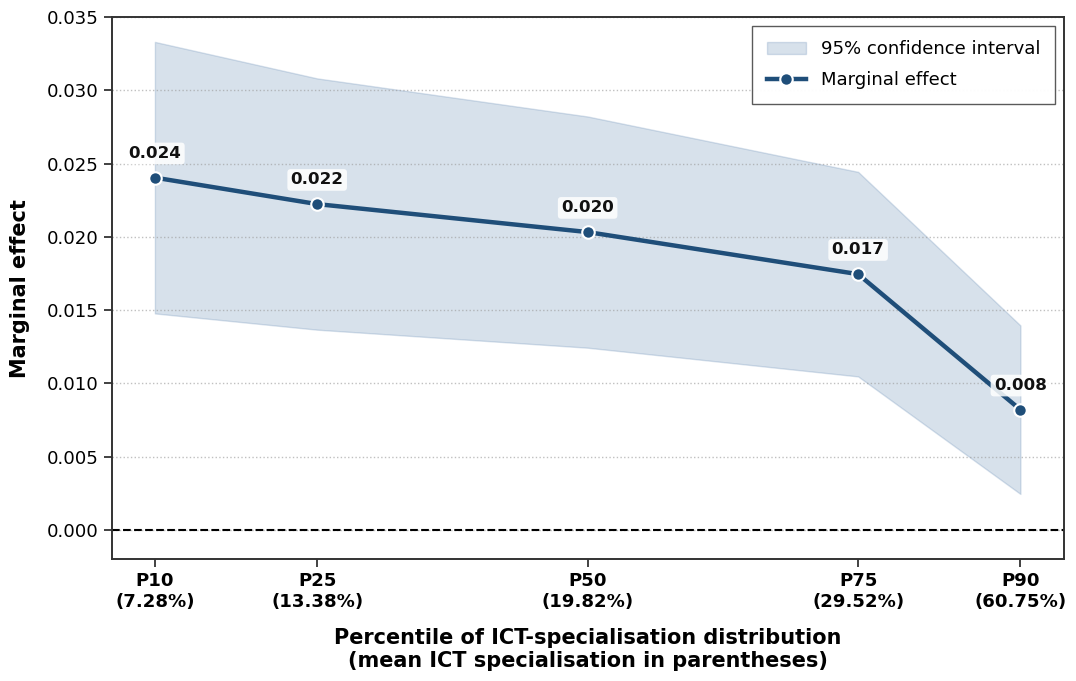

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data
percentiles = np.array([10, 25, 50, 75, 90])
spec_ict_mean = np.array([7.28, 13.38, 19.82, 29.52, 60.75])

marginal_effect = np.array([
    0.024038,
    0.022231,
    0.020322,
    0.017450,
    0.008198
])

ci_lower = np.array([
    0.01477,
    0.01366,
    0.01243,
    0.01047,
    0.00245
])

ci_upper = np.array([
    0.03330,
    0.03081,
    0.02821,
    0.02443,
    0.01395
])

# Global font settings
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 13,
    "axes.labelsize": 15,
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
    "legend.fontsize": 13
})

# Figure
fig, ax = plt.subplots(figsize=(11, 7))

# Confidence interval band
ax.fill_between(
    percentiles,
    ci_lower,
    ci_upper,
    color="#4C78A8",
    alpha=0.22,
    label="95% confidence interval",
    zorder=1
)

# Marginal-effect line
ax.plot(
    percentiles,
    marginal_effect,
    color="#1F4E79",
    linewidth=3.2,
    marker="o",
    markersize=9,
    markerfacecolor="#1F4E79",
    markeredgecolor="white",
    markeredgewidth=1.5,
    label="Marginal effect",
    zorder=3
)

# Reference line at zero
ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.5,
    zorder=2
)

# Labels for marginal-effect estimates
for p, me in zip(percentiles, marginal_effect):
    ax.annotate(
        f"{me:.3f}",
        xy=(p, me),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
        color="#111111",
        bbox=dict(
            boxstyle="round,pad=0.20",
            facecolor="white",
            edgecolor="none",
            alpha=0.85
        ),
        zorder=4
    )

# X-axis labels
ax.set_xticks(percentiles)
ax.set_xticklabels(
    [f"P{p}\n({ict:.2f}%)" for p, ict in zip(percentiles, spec_ict_mean)],
    fontweight="semibold"
)

# Axis labels
ax.set_xlabel(
    "Percentile of ICT-specialisation distribution\n"
    "(mean ICT specialisation in parentheses)",
    fontweight="bold",
    labelpad=12
)
ax.set_ylabel(
    "Marginal effect",
    fontweight="bold",
    labelpad=12
)

for spine in ax.spines.values():
    spine.set_linewidth(1.4)
    spine.set_color("#333333")

ax.tick_params(
    axis="both",
    which="major",
    length=6,
    width=1.3,
    color="#333333"
)


ax.grid(
    axis="y",
    linestyle=":",
    linewidth=1,
    color="#9E9E9E",
    alpha=0.65,
    zorder=0
)


ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#555555",
    framealpha=0.97,
    fancybox=False,
    borderpad=0.8,
    labelspacing=0.7,
    handlelength=2.2
)

ax.set_ylim(-0.002, 0.035)
plt.tight_layout()
plt.show()

## 9. Country fixed-effects variants (C(geo))

Re-runs the CRE specifications with an explicit country fixed effect (`C(geo)`) added.


In [9]:
exec(open("model_functions/cre_interaction_geo.py").read())
results = run_full_analysis(df_master)

CRE/Mundlak model loaded. Run: results = run_full_analysis(df_master)

####################################################################
  SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 708
  - Clean observations:   472
  - Dropped (Missing):    236 rows

  CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                          0.00005    0.00148    0.9715  
  spec_ict                             0.00108    0.00105    0.3020  
  ai_x_spec_ict                       -0.00000    0.00003    0.9365  
  log_prod                             0.04486    0.03030    0.1387  
  FSI                                 -0.00013    0.00025    0.6129  
  tert_edu                            -0.00036    0.00118 

In [13]:
exec(open("model_functions/cre_additive_geo.py").read())
results = run_additive_analysis(df_master)

Additive CRE (Complete Cases Fix + Prod/FSI) script loaded. Run: results_add = run_additive_analysis(df_master)

####################################################################
  ADDITIVE SPECIFICATION A — ICT SPECIALISTS + tert_edu (WITH FSI & PROD)
####################################################################

  [Data Diagnostics] ICT Specialists:
  - Initial observations: 708
  - Clean observations:   472
  - Dropped (Missing):    236 rows

  ADDITIVE CRE / MUNDLAK MODEL — ICT SPECIALISTS

  Variable                                Coef         SE     p-val  Sig
  ------------------------------------------------------------------
  ai_adoption                         -0.00005    0.00077    0.9488  
  spec_ict                             0.00105    0.00093    0.2576  
  log_prod                             0.04505    0.03024    0.1363  
  FSI                                 -0.00013    0.00025    0.6099  
  tert_edu                            -0.00036    0.00118    0.7604 